Shape of X and y = (1000, 2),(1000,)


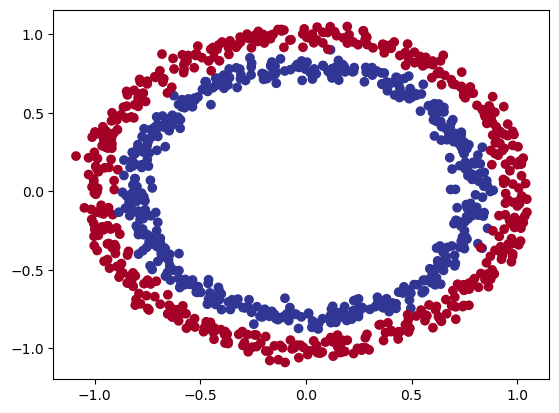

In [76]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
X,y=make_circles(n_samples=1000,noise=0.04,random_state=42)

print(f"Shape of X and y = {X.shape},{y.shape}")
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);


In [77]:
import torch
from torch import nn

In [78]:
from sklearn.model_selection import train_test_split
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [79]:
from torch import nn
class NeuralNetwork(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layer_1=nn.Linear(in_features=2,out_features=10)
        self.layer_2=nn.Linear(in_features=10,out_features=10)
        self.layer_3=nn.Linear(in_features=10,out_features=1)
        self.relu=nn.ReLU()
        
    def forward(self, x): 
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [80]:
model=NeuralNetwork()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.4914, -0.6816],
                      [ 0.4047, -0.2487],
                      [ 0.1405, -0.3624],
                      [-0.2880, -0.6501],
                      [-0.6603,  0.1132],
                      [ 0.3778, -0.5390],
                      [ 0.1921,  0.4768],
                      [-0.5785,  0.5119],
                      [ 0.2474,  0.6270],
                      [-0.5716,  0.4156]])),
             ('layer_1.bias',
              tensor([-0.6696,  0.2151,  0.2507,  0.2517,  0.3570,  0.3495, -0.4587,  0.4860,
                       0.0150,  0.0862])),
             ('layer_2.weight',
              tensor([[-0.0900,  0.2517, -0.2959, -0.2539, -0.2983, -0.0980, -0.1004,  0.0028,
                        0.2500,  0.2061],
                      [-0.1551, -0.2659, -0.1484,  0.2934, -0.3021,  0.0846,  0.1970,  0.0739,
                       -0.2755, -0.0777],
                      [ 0.0509, -0.1553, -0.2328, -0.2337, -0.0781,  0.2

In [81]:
loss_fn = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)

In [82]:
def accuracy_fn(y_true, y_pred): 
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct/len(y_true))*100 
    return acc

In [83]:
epochs = 500 
train_loss_list = []
test_loss_list = []
for epoch in range(epochs):
    model.train()
    # Forward pass
    y_logits=model(X_train).squeeze()
    y_preds=torch.round(torch.sigmoid(y_logits))

    #compute the train loss
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    # Optimizer Zero Grad 
    optimizer.zero_grad()

    #backpropagate
    train_loss.backward()

    # Step the optimizer
    optimizer.step()

    # Testing
    
    model.eval() 
    with torch.inference_mode(): 
        test_logits = model(X_test).squeeze() 
        test_preds = torch.round(torch.sigmoid(test_logits)) 
        test_loss = loss_fn(test_logits, y_test) 
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds) 
    train_loss_list.append(train_loss.item()) 
    test_loss_list.append(test_loss.item()) 
    if (epoch+1) % 100 == 0: 
        print(f'Epoch {epoch+1}|Loss {train_loss:.5f}|Acc {train_acc:.2f}|Test Loss {test_loss:.5f}|Test Acc {test_acc:.2f}')






Epoch 100|Loss 0.69673|Acc 44.62|Test Loss 0.69701|Test Acc 40.50
Epoch 200|Loss 0.69475|Acc 44.88|Test Loss 0.69484|Test Acc 40.50
Epoch 300|Loss 0.69317|Acc 42.25|Test Loss 0.69311|Test Acc 43.00
Epoch 400|Loss 0.69162|Acc 50.75|Test Loss 0.69154|Test Acc 55.00
Epoch 500|Loss 0.69015|Acc 59.50|Test Loss 0.69011|Test Acc 58.50


Text(0.5, 1.0, 'Epochs vs Loss')

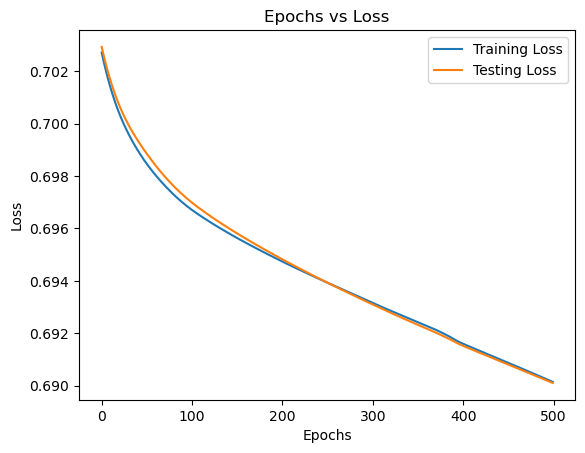

In [ ]:
plt.plot(range(epochs), train_loss_list, label="Training Loss") 
plt.plot(range(epochs), test_loss_list, label="Testing Loss") 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.legend() 
plt.title("Epochs vs Loss")